In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Image Pair Counts : MGO01_low_light cam0 : 535
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam1 : 562
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam0 : 556
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam1 : 555
INFO     | setup | Train Dataset       : 2208 samples
INFO     | _get_names | Image Pair Counts : MOO09_short_1_updown cam0 : 6
INFO     | _get_names | Image Pair Counts : MOO09_short_1_updown cam1 : 6
INFO     | _get_names | Image Pair Counts : MGO09_short_1_updown cam0 : 8
INFO     | _get_names | Image Pair Counts : MGO09_short_1_updown cam1 : 7
INFO     | _get_names | Image Pair Counts : MGO10_short_2_panorama cam0 : 21
INFO     | _get_names | Image Pair Counts : MGO10_short_2_panorama cam1 : 21
INFO     | _get_names | Image Pair Counts : MOO10_short_2_panorama cam0 : 21
INFO     | _get_names | Image Pair Counts : MOO10_short_2_panorama cam1 : 21
INFO     | setup | Validation Dataset  : 111 samples

In [4]:
dl = dm.train_dataloader()

In [5]:
batch = next(iter(dl))

In [6]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

rotations = batch.rotations
print(rotations.shape)

torch.Size([59, 3, 32, 32]) torch.Size([59, 3, 32, 32])
torch.Size([59, 2]) torch.Size([59, 2])
torch.Size([59])


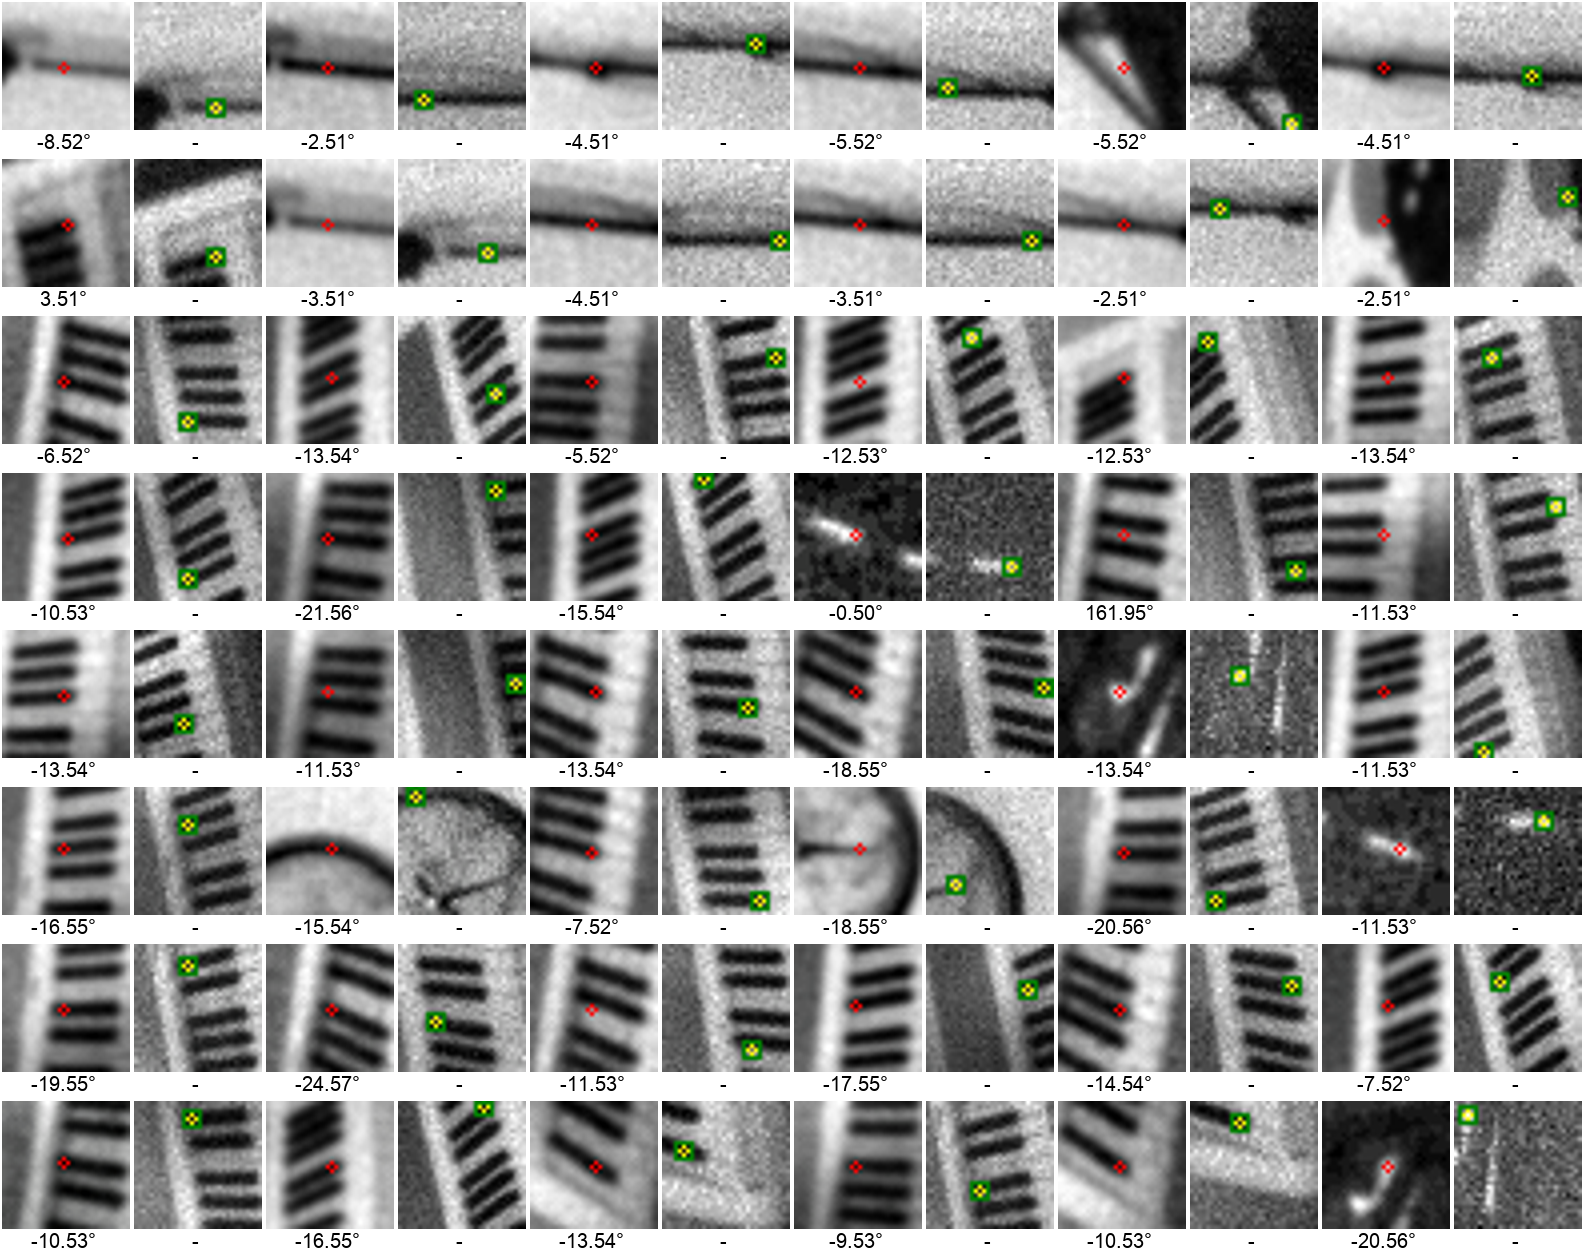

In [7]:
# batch = next(iter(dl))

count = 24 * 2

# radians to degrees
# print(batch.rotations[:count] * (180 / torch.pi))

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    rotations_true=batch.rotations,
    rotations=None,
    limit_count=count, 
    n_columns=6,
)

In [8]:
for index, batch in enumerate(dl):
    print(f'-- Batch Index {index} -----')
    reference_patches = batch.reference_patches
    target_patches = batch.target_patches
    print(reference_patches.shape, target_patches.shape) 

    patch_level_reference_coords = batch.patch_level_reference_coords
    patch_level_target_coords = batch.patch_level_target_coords
    print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

    rotations = batch.rotations
    print(rotations.shape)

-- Batch Index 0 -----
torch.Size([170, 3, 32, 32]) torch.Size([170, 3, 32, 32])
torch.Size([170, 2]) torch.Size([170, 2])
torch.Size([170])
-- Batch Index 1 -----
torch.Size([61, 3, 32, 32]) torch.Size([61, 3, 32, 32])
torch.Size([61, 2]) torch.Size([61, 2])
torch.Size([61])
-- Batch Index 2 -----
torch.Size([72, 3, 32, 32]) torch.Size([72, 3, 32, 32])
torch.Size([72, 2]) torch.Size([72, 2])
torch.Size([72])
-- Batch Index 3 -----
torch.Size([53, 3, 32, 32]) torch.Size([53, 3, 32, 32])
torch.Size([53, 2]) torch.Size([53, 2])
torch.Size([53])
-- Batch Index 4 -----
torch.Size([76, 3, 32, 32]) torch.Size([76, 3, 32, 32])
torch.Size([76, 2]) torch.Size([76, 2])
torch.Size([76])
-- Batch Index 5 -----
torch.Size([52, 3, 32, 32]) torch.Size([52, 3, 32, 32])
torch.Size([52, 2]) torch.Size([52, 2])
torch.Size([52])
-- Batch Index 6 -----
torch.Size([152, 3, 32, 32]) torch.Size([152, 3, 32, 32])
torch.Size([152, 2]) torch.Size([152, 2])
torch.Size([152])
-- Batch Index 7 -----
torch.Size([100

-- Batch Index 24 -----
torch.Size([87, 3, 32, 32]) torch.Size([87, 3, 32, 32])
torch.Size([87, 2]) torch.Size([87, 2])
torch.Size([87])
-- Batch Index 25 -----
torch.Size([64, 3, 32, 32]) torch.Size([64, 3, 32, 32])
torch.Size([64, 2]) torch.Size([64, 2])
torch.Size([64])
-- Batch Index 26 -----
torch.Size([59, 3, 32, 32]) torch.Size([59, 3, 32, 32])
torch.Size([59, 2]) torch.Size([59, 2])
torch.Size([59])
-- Batch Index 27 -----
torch.Size([155, 3, 32, 32]) torch.Size([155, 3, 32, 32])
torch.Size([155, 2]) torch.Size([155, 2])
torch.Size([155])
-- Batch Index 28 -----
torch.Size([141, 3, 32, 32]) torch.Size([141, 3, 32, 32])
torch.Size([141, 2]) torch.Size([141, 2])
torch.Size([141])
-- Batch Index 29 -----
torch.Size([79, 3, 32, 32]) torch.Size([79, 3, 32, 32])
torch.Size([79, 2]) torch.Size([79, 2])
torch.Size([79])
-- Batch Index 30 -----
torch.Size([195, 3, 32, 32]) torch.Size([195, 3, 32, 32])
torch.Size([195, 2]) torch.Size([195, 2])
torch.Size([195])
-- Batch Index 31 -----
to

In [9]:
dm.teardown()

# Check Model

In [10]:
from src import Light
light = Light()

In [11]:
from utils import count_params
count_params(light.model)

416388

In [12]:
print('Model Inputs')
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

print('Model Outputs')

target_coords, target_rotation, target_confidence = light(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(f'target_coords shape : {target_coords.shape}')
print(f'target_rotation shape : {target_rotation.shape}')
print(f'target_confidence shape : {target_confidence.shape}')

Model Inputs
reference_patches shape : torch.Size([171, 3, 32, 32])
target_patches shape : torch.Size([171, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([171, 2])
Model Outputs
target_coords shape : torch.Size([171, 2])
target_rotation shape : torch.Size([171, 1])
target_confidence shape : torch.Size([171, 1])
